In [1]:
import json
import numpy as np
import pandas as pd
import dask.dataframe as dd
import geopandas as gpd
from itertools import chain
root_dir = "/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/"

In [2]:
# import data
rivers = gpd.read_feather(f"{root_dir}data/river_network/shapefile.feather")
drainage_polygons = gpd.read_feather(f"{root_dir}data/drainage/extracted_drainage_polygons.feather")
land_cover = dd.read_parquet(f"{root_dir}data/land_cover/temp_extracted_land_cover/", columns=["year", "deforestation", "deforestation_p", "deforestation_a", "deforestation_u", "deforestation_m", "forest", "pasture", "agriculture", "urban", "mining", "total"]).astype(np.uint32)
cloud_cover = dd.read_parquet(f"{root_dir}data/cloud_cover/cloud_cover.parquet").astype({"grid_id": "uint32", "index": "uint32", "year": "uint32", "cloud_cover": "float32"})

In [4]:
# prepare deforestation data in dask dataframe
t_deforestation = land_cover.groupby(["grid_id", "index", "year"]).sum().reset_index().astype(np.uint32).persist()
del land_cover

In [97]:
## aggregation within adm2 regions

# prepare a table from adm2 to grid_id
adm2_table = pd.merge(
    rivers[["adm2", "estuary", "river", "segment", "subsegment"]], 
    drainage_polygons[["estuary", "river", "segment", "subsegment"]].reset_index(names = ["grid_id", "index"]), 
    on=["estuary", "river", "segment", "subsegment"], how="right",
    ).dropna()[["grid_id", "index", "adm2"]].astype(np.uint32)

In [103]:
# merge deforestation data with adm2
t_deforestation_adm = dd.merge(t_deforestation, dd.from_pandas(adm2_table, npartitions=1), on=["grid_id", "index"], how="left")
# calculate deforestation data for each adm2
c_final_df_deforestation = t_deforestation_adm.drop(columns=["grid_id", "index"]).groupby(["adm2", "year"]).sum().compute()

In [105]:
# merge cloud cover data with adm2
t_cloud_cover_adm = dd.merge(cloud_cover, dd.from_pandas(adm2_table, npartitions=1), on=["grid_id", "index"], how="left")
# calculate cloud cover data for each adm2
c_final_df_cloud_cover = t_cloud_cover_adm.drop(columns=["grid_id", "index"]).groupby(["adm2", "year"]).mean().compute()

In [111]:
# merge deforestation and cloud cover data
out_df = pd.merge(c_final_df_deforestation, c_final_df_cloud_cover, on=["adm2", "year"], how="left")

In [113]:
# write GID
out_df = out_df.reset_index().astype({"year": np.int16})
out_df["municipality"] = out_df.adm2.map(id_gid_lookup)
out_df.drop(columns=["adm2"], inplace=True)

# save to parquet
out_df.to_parquet(f"{root_dir}data/deforestation/deforestation.parquet", index=False)

In [115]:
## aggregation in upstream nodes
# compute lookup from node to list of polygons
drainage_polygons_tmp = drainage_polygons[((~ drainage_polygons.is_empty) & (~ drainage_polygons.geometry.isna()))].drop(columns="geometry").reset_index(names = ["grid", "index"])
drainage_polygons_tmp = pd.merge(drainage_polygons_tmp, rivers.drop(columns = ["NORIOCOMP", "CORIO", "geometry"]), on = ["estuary", "river", "segment", "subsegment"])
drainage_polygons_tmp["identifier"] = drainage_polygons_tmp.apply(lambda x: [x["grid"], x["index"]], axis = 1)
node_polygon_lookup = drainage_polygons_tmp.set_index("upstream_node_id").groupby(level=0).apply(lambda x: x["identifier"].tolist()).to_dict()

: 

In [6]:
# import reachability data
reachability_municipalities = json.load(open("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/river_network/reachability_municipalities.json", "r"))

## convert to integer ID
# load municipalities
municipalities = gpd.read_file("/pfs/work7/workspace/scratch/tu_zxobe27-master_thesis/data/misc/raw/gadm/gadm41_BRA_2.json", engine="pyogrio")
# create mapping from GID_2 to integer ID
gid_id_lookup = municipalities["GID_2"].reset_index().set_index("GID_2")["index"].to_dict()
id_gid_lookup = municipalities["GID_2"].to_dict()
# convert reachability_municipalities keys to integer ID
reachability_municipalities = {gid_id_lookup.get(k, k): v for k, v in reachability_municipalities.items()}

In [7]:
## chunk all municipalities into chunks if 1M nodes
# assign chunks of 1M nodes
t_chunks = np.cumsum([len(x) if x is not None else 0 for i, x in reachability_municipalities.items()]) // 5e5
# get indices of chunks
t_chunks = [(int(np.argmax(t_chunks == i)), int(len(t_chunks) - np.argmax(t_chunks[::-1] == i) - 1)) for i in np.unique(t_chunks)]
# get nodes split into chunks
c_node_ids = [{y: reachability_municipalities[y] for y in list(reachability_municipalities.keys())[x[0]:x[1]]} for x in t_chunks]

In [74]:
# iterate over chunks
out_df = [None] * len(c_node_ids)
for i in [0]:#range(len(c_node_ids)):
    ## prepare data frame for final estimation
    # get polygon ids
    t_index_prep = {(key, int(value)): node_polygon_lookup.get(value, [None, None]) for key, values in c_node_ids[i].items() if values is not None for value in values}
    # combine in tuple for index
    t_index_prep = [(key[0], key[1], int(value[0]), int(value[1])) for key, values in t_index_prep.items() for value in values if value is not None]         
    # create dataframe with indices
    c_final_df = dd.from_pandas(pd.DataFrame().from_records(t_index_prep, columns = ["municipality", "node", "grid_id", "index"])).astype(np.uint32)
    # merge with deforestation data and summarize
    c_final_df_deforestation = dd.merge(c_final_df, t_deforestation, on = ["grid_id", "index"], how = "left")
    c_final_df_deforestation = c_final_df_deforestation.drop(columns=["grid_id", "index", "node"]).groupby(["municipality", "year"]).sum().compute().astype(np.float32)
    # merge with cloud cover data and summarize
    c_final_df_cloud_cover = dd.merge(c_final_df, cloud_cover, on = ["grid_id", "index"], how = "left")
    c_final_df_cloud_cover = c_final_df_cloud_cover.groupby(["municipality", "year"]).agg({"cloud_cover": "mean"}).compute().astype(np.float32)
    # Group by the bins and sum the value column
    #agg_dict = {"deforestation": "sum", "deforestation_p": "sum", "deforestation_a": "sum", "deforestation_u": "sum", "deforestation_m": "sum", "forest": "sum", "pasture": "sum", "agriculture": "sum", "urban": "sum", "mining": "sum", "total": "sum"}
    out_df[i] = pd.merge(c_final_df_deforestation, c_final_df_cloud_cover, on = ["municipality", "year"], how = "outer")

In [75]:
# combine all chunks
out_df = pd.concat(out_df).reset_index().astype({"year": np.int16})
# get GID_2
out_df["municipality"] = out_df.municipality.map(id_gid_lookup)


In [ ]:
# save to parquet
out_df.to_parquet(f"{root_dir}data/land_cover/land_cover_municipalities_agg.parquet")

---

In [1]:
import numpy as np
from scipy.sparse import csr_matrix
import pandas as pd
import geopandas as gpd
import sys
sys.path.append("../data")
from river_network import river_network

# Load existing network
network = river_network.load_network(
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network/shapefile.parquet",
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network/topology.parquet",
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network/distance_from_estuary.parquet"
)

In [2]:
# we focus on one single ADM region
it_adm2 = int(network.shapefile.adm2.unique()[0])
it_adm2

3110

In [3]:
# we get all EIDS of the edges in this ADM region
it_eids = np.asarray(network.shapefile.query(f"adm2=={it_adm2}").index.tolist())
it_eids

array([[    0,     0,     0],
       [    7,     0,     0],
       [33765,     0,     0],
       [35085,     0,     0],
       [35085,     0,     1],
       [36096,     0,     2],
       [36679,     0,     3],
       [36679,     0,     4],
       [40516,     0,     0],
       [42141,     0,   612],
       [42141,     0,   613],
       [42141,     0,   614]])

In [4]:
# we get the reachability for those EIDS

def row_indices(long, short):
    dtype = np.dtype([('f0', long.dtype), ('f1', long.dtype), ('f2', long.dtype)])
    long_view = long.view(dtype).ravel()
    short_view = short.view(dtype).ravel()
    return np.where(np.isin(long_view, short_view))[0]

it_reachability_indices = row_indices(
    network.reachability["edge_ids"],
    it_eids
    )

it_reachability = network.reachability["matrix"][it_reachability_indices,:]
it_reachability

<Compressed Sparse Row sparse array of dtype 'float32'
	with 31907 stored elements and shape (12, 421657)>

In [6]:
# we collapse this to minimums larger than 0
 
def min_nonzero_axis0(A):
    A = A.tocsc()
    mins = np.full(A.shape[1], np.inf)
    np.minimum.at(mins, np.repeat(np.arange(A.shape[1]), np.diff(A.indptr)), A.data)
    return mins

it_reachability_agg = min_nonzero_axis0(it_reachability)
it_reachability_agg

array([ 0., inf, inf, ..., inf, inf, inf], shape=(421657,))

In [7]:
# we get eids and distances

it_reachable_eids = network.reachability["edge_ids"][~np.isinf(it_reachability_agg)]
it_reachable_distances = it_reachability_agg[~np.isinf(it_reachability_agg)]

In [8]:
# load and aggregate land cover by eid

land_cover = pd.read_feather("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/land_cover/land_cover_results.feather")

drainge_polygons = gpd.read_feather("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/drainage/extracted_drainage_polygons_filtered.feather")

eid_pid_table = pd.merge(
    network.shapefile[["estuary", "river", "segment", "subsegment"]].reset_index(names=["eid_0", "eid_1", "eid_2"]),
    drainge_polygons[["estuary", "river", "segment", "subsegment"]].reset_index(names=["pid"])
)

land_cover_agg = pd.merge(
    eid_pid_table,
    land_cover.rename(columns={"id": "pid"})
).\
    groupby(["eid_0", "eid_1", "eid_2", "year"])[["0", "1", "2", "3", "4", "20", "21", "30", "31"]].\
        agg("sum").\
            sort_index()

In [9]:
land_cover_agg

0  1     2  3  4    20   21  30  31
eid_0  eid_1 eid_2 year                                       
1      0     0     1985  105  0  9530  0  0  6718  905   0   0
                   1986  105  0  9530  0  0  7059  904   0   0
                   1987   76  0  9559  0  0  7877  426   0   0
                   1988   76  0  9559  0  0  7972  327   0   0
                   1989   76  0  9559  0  0  8114  273   0   0
...                      ... ..   ... .. ..   ...  ...  ..  ..
161510 0     0     2020   45  0     0  0  0     0    0   0   0
                   2021   45  0     0  0  0     0    0   0   0
                   2022   42  0     0  0  3     0    0   0   0
                   2023   45  0     0  0  0     0    0   0   0
                   2024   45  0     0  0  0     0    0   0   0

[8498560 rows x 9 columns]

In [10]:
import numpy as np
import pandas as pd

def distance_weights(distances, kernel="gaussian", h=1000):
    d = np.asarray(distances, dtype=float)
    if kernel == "uniform":
        w = (d <= h).astype(float)
    elif kernel == "triangular":
        w = np.clip(1 - d/h, 0, None)
    elif kernel == "epanechnikov":
        w = np.clip(1 - (d/h)**2, 0, None)
    elif kernel == "gaussian":
        w = np.exp(-(d/h)**2)
    elif kernel == "exponential":
        w = np.exp(-d/h)
    else:
        raise ValueError(f"Unknown kernel: {kernel}")
    return w


In [11]:
# Convert EID array to a MultiIndex
it_eid_index = pd.MultiIndex.from_arrays(it_reachable_eids.T, names=["eid_0", "eid_1", "eid_2"])

# Boolean mask to select rows (all years)
it_eid_index_mask = land_cover_agg.index.droplevel("year").isin(it_eid_index)
it_df_matched = land_cover_agg.loc[it_eid_index_mask]


In [13]:
# distances: (n,) array corresponding to each eid
# match to df_matched
# First, build a mapping from EID -> distance
pid_to_dist = {tuple(pid): d for pid, d in zip(it_reachable_eids, it_reachable_distances)}

# Map distances to the selected rows
it_df_dist = it_df_matched.index.droplevel("year").map(lambda x: pid_to_dist.get(x, np.nan))
it_df_dist = np.asarray(it_df_dist)
it_df_dist

array([207011., 207011., 207011., ..., 188992., 188992., 188992.],
      shape=(126480,))

In [20]:
kernels = ["uniform", "triangular", "epanechnikov", "gaussian", "exponential"]
h = 1000 * 1e3  # bandwidth in meters, adjust as needed

agg_results = {}

for k in kernels:
    w = distance_weights(it_df_dist, kernel=k, h=h)
    
    # Weighted mean per column
    weighted_mean = np.sum(it_df_matched.values * w[:, None], axis=0) / np.sum(w)
    
    agg_results[k] = pd.Series(weighted_mean, index=land_cover_agg.columns)


In [23]:
agg_results

{'uniform': 0      5357.891888
 1       580.709543
 2     21219.059843
 3       282.136891
 4       530.437698
 20     6997.977751
 21     8020.970723
 30      256.587468
 31        2.117386
 dtype: float64,
 'triangular': 0      4709.487564
 1       508.208455
 2     22103.619772
 3       289.035345
 4       626.170008
 20     7441.636464
 21     8722.372920
 30      264.699574
 31        1.365893
 dtype: float64,
 'epanechnikov': 0      4975.463812
 1       541.566495
 2     21703.255485
 3       285.556236
 4       583.046872
 20     7259.971541
 21     8367.803906
 30      260.685977
 31        1.614842
 dtype: float64,
 'gaussian': 0      5060.168434
 1       548.344679
 2     21599.800937
 3       285.150955
 4       571.761724
 20     7198.245191
 21     8305.802572
 30      260.155528
 31        1.740020
 dtype: float64,
 'exponential': 0      4973.519540
 1       536.517530
 2     21759.942383
 3       286.430524
 4       588.884810
 20     7262.032688
 21     8463.672338
 30 

---

# Sanity check for Rio

In [1]:
import pandas as pd
import sys
import geopandas as gpd
import shapely
sys.path.append("..")
from data.river_network import RiverNetwork

In [2]:
network = RiverNetwork()
network.load("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network")

In [8]:
rio = shapely.box(-43.4, -22.85, -43, -22.7)

In [62]:
area_subset = network.drainage_areas.clip_by_rect(-43.4, -23, -43, -22.5)
area_subset = network.drainage_areas.loc[~ area_subset.is_empty]

In [143]:
area_subset_simplified = area_subset.copy()
area_subset_simplified["geometry"] = area_subset_simplified.simplify(.0001)

In [140]:
area_subset.geometry.apply(lambda x: sum([len(y.boundary.coords) for y in x.geoms])).sum()

np.int64(17508)

In [142]:
area_subset_simplified.geometry.apply(lambda x: len(x.boundary.coords)).sum()

np.int64(2808)

<Axes: >

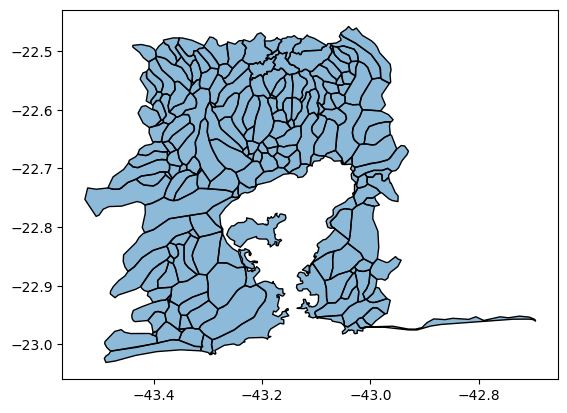

In [126]:
ax = area_subset.plot(alpha=.5)
area_subset_simplified.plot(ax=ax, color="none", edgecolor="black")

In [ ]:
land_cover = pd.read_feather("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/land_cover/land_cover.feather")
land_cover["land_cover_total"] = land_cover.loc[:,['land_cover_class_0', 'land_cover_class_1', 'land_cover_class_2', 'land_cover_class_3', 'land_cover_class_4']].sum(axis=1)

In [86]:
land_cover_subset = land_cover.loc[((land_cover.trench_id.isin(area_subset.trench_id)) & (land_cover.year == 2020))].copy()
land_cover_subset.loc[:,"land_cover_total"] = land_cover_subset.loc[:,['land_cover_class_0', 'land_cover_class_1', 'land_cover_class_2', 'land_cover_class_3', 'land_cover_class_4']].sum(axis=1)
land_cover_subset.loc[:,"forest_share"] = land_cover_subset.loc[:,"land_cover_class_0"] / land_cover_subset.loc[:,"land_cover_total"]
land_cover_subset.loc[:,"agriculture_share"] = (land_cover_subset.loc[:,"land_cover_class_2"] + land_cover_subset.loc[:,"land_cover_class_20"] + land_cover_subset.loc[:,"land_cover_class_21"]) / land_cover_subset.loc[:,"land_cover_total"]
land_cover_subset.loc[:,"urban_share"] = land_cover_subset.loc[:,"land_cover_class_3"] / land_cover_subset.loc[:,"land_cover_total"]

In [87]:
merged_subset = pd.merge(
    area_subset,
    land_cover_subset,
    on="trench_id"
)

<Axes: >

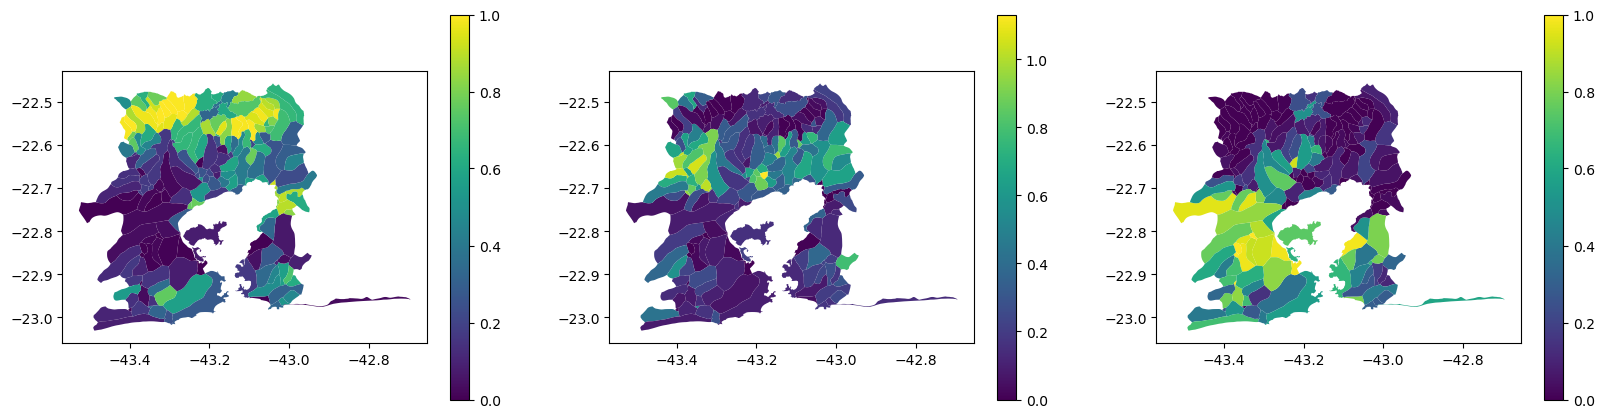

In [88]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

merged_subset.plot(ax=ax[0], column="forest_share", legend=True)
merged_subset.plot(ax=ax[1], column="agriculture_share", legend=True)
merged_subset.plot(ax=ax[2], column="urban_share", legend=True)

<Axes: ylabel='Frequency'>

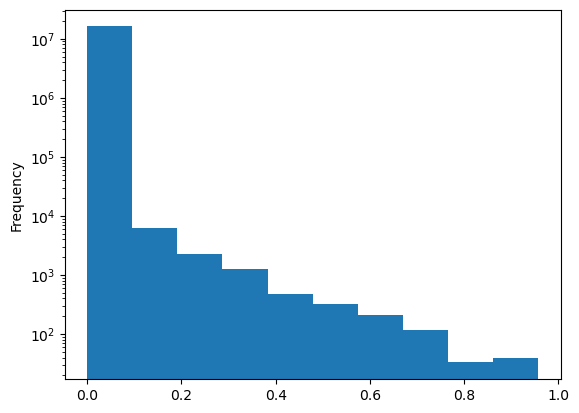

In [96]:
(land_cover.land_cover_class_31 / land_cover.land_cover_total).plot(kind="hist", logy=True)

In [105]:
# each pixel is 30m*30m at the equator. area is therefore 900m^2
(land_cover.land_cover_class_31 * 900).sum() / 1e6

np.float64(91461.4614)

In [106]:
(land_cover.land_cover_total * 900).sum() / 1e6

np.float64(357368518.9476)

---

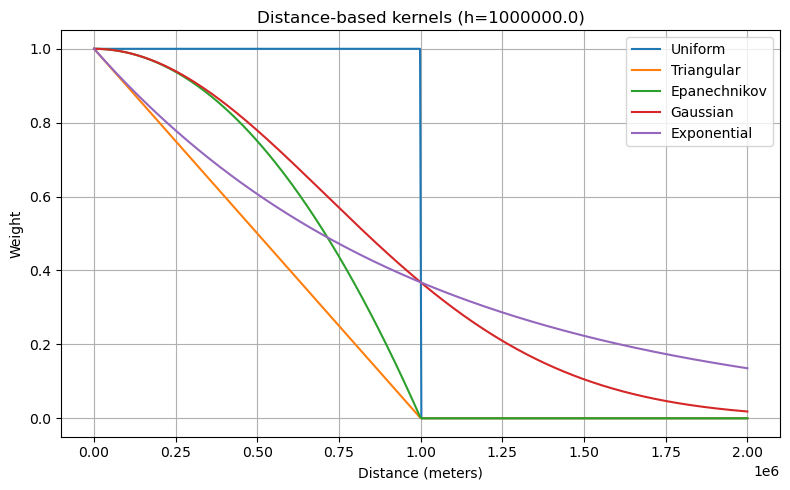

In [102]:
import numpy as np
import matplotlib.pyplot as plt

def plot_distance_kernels(h=1000, max_distance=None, kernels=None):
    """
    Visualize distance-based kernels.
    
    Parameters
    ----------
    h : float
        Bandwidth (in meters) for the kernels.
    max_distance : float, optional
        Maximum distance to plot. Defaults to 2*h.
    kernels : list of str, optional
        List of kernels to plot. Defaults to common kernels.
        Options: 'uniform', 'triangular', 'epanechnikov', 'gaussian', 'exponential'
    """
    if kernels is None:
        kernels = ['uniform', 'triangular', 'epanechnikov', 'gaussian', 'exponential']
    
    if max_distance is None:
        max_distance = 2 * h
    
    distances = np.linspace(0, max_distance, 500)
    
    plt.figure(figsize=(8, 5))
    
    for k in kernels:
        if k == 'uniform':
            w = (distances <= h).astype(float)
        elif k == 'triangular':
            w = np.clip(1 - distances/h, 0, None)
        elif k == 'epanechnikov':
            w = np.clip(1 - (distances/h)**2, 0, None)
        elif k == 'gaussian':
            w = np.exp(-(distances/h)**2)
        elif k == 'exponential':
            w = np.exp(-distances/h)
        else:
            raise ValueError(f"Unknown kernel: {k}")
        
        plt.plot(distances, w, label=k.capitalize())
    
    plt.xlabel("Distance (meters)")
    plt.ylabel("Weight")
    plt.title(f"Distance-based kernels (h={h})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_distance_kernels(h=1000 * 1e3)